# Comparing distributions

Hypergrid provides four divergence metrics for comparing two grids:

| Method | Description | Symmetric |
|---|---|---|
| `l1` | Total variation distance | Yes |
| `js` | Jensen-Shannon divergence, bounded in [0, 1] | Yes |
| `kl` | Kullback-Leibler divergence | No |
| `wasserstein` | Earth Mover's Distance via LP | Yes |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from hypergrid import DenseHypergrid, compute_edges

## 1. Two identical distributions → divergence should be 0

In [2]:
rng = np.random.default_rng(0)
data = rng.standard_normal((3000, 2))
edges = compute_edges(data)

g1 = DenseHypergrid(edges)
g2 = DenseHypergrid(edges)
g1.fit(data)
g2.fit(data)

for method in ["l1", "js", "kl"]:
    print(f"{method:12s}: {g1.compare(g2, method=method):.6f}")

l1          : 0.000000
js          : 0.000000
kl          : 0.000000


## 2. Shifted distribution — increasing divergence with shift magnitude

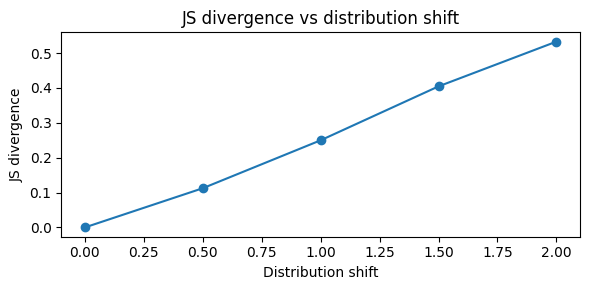

In [3]:
shifts = [0.0, 0.5, 1.0, 1.5, 2.0]
js_values = []

baseline = rng.standard_normal((2000, 2))
full_edges = compute_edges(np.vstack([baseline, baseline + max(shifts)]))

g_base = DenseHypergrid(full_edges)
g_base.fit(baseline)

for shift in shifts:
    shifted = baseline + shift
    g_shifted = DenseHypergrid(full_edges)
    g_shifted.fit(shifted)
    js_values.append(g_base.compare(g_shifted, method="js"))

plt.figure(figsize=(6, 3))
plt.plot(shifts, js_values, marker="o")
plt.xlabel("Distribution shift")
plt.ylabel("JS divergence")
plt.title("JS divergence vs distribution shift")
plt.tight_layout()
plt.show()

## 3. All divergence metrics side by side

In [4]:
g_shifted = DenseHypergrid(full_edges)
g_shifted.fit(baseline + 1.5)

methods = ["l1", "js", "kl"]
for m in methods:
    print(f"{m:12s}: {g_base.compare(g_shifted, method=m):.4f}")

l1          : 1.4590
js          : 0.4045
kl          : 9.0464


## 4. Wasserstein distance (Earth Mover's Distance)

Uses LP — run on a small grid to keep it fast.

In [5]:
small_edges = [np.linspace(-3, 3, 7), np.linspace(-3, 3, 7)]

w1 = DenseHypergrid(small_edges)
w2 = DenseHypergrid(small_edges)
w1.fit(rng.standard_normal((500, 2)))
w2.fit(rng.standard_normal((500, 2)) + 1.5)

print(f"Wasserstein: {w1.compare(w2, method='wasserstein'):.4f}")

Wasserstein: 1.9705


## 5. Marginal comparison

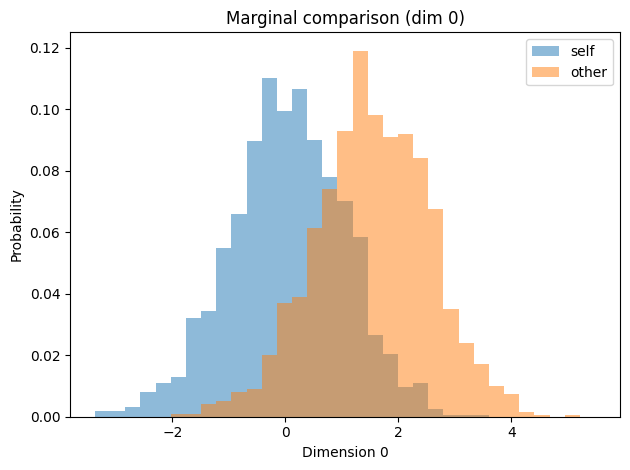

In [6]:
g_base.compare_marginal(g_shifted, dim=0)

## 6. UMAP comparison

c:\Users\cleme\PROJECTS\HYPERGRID\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


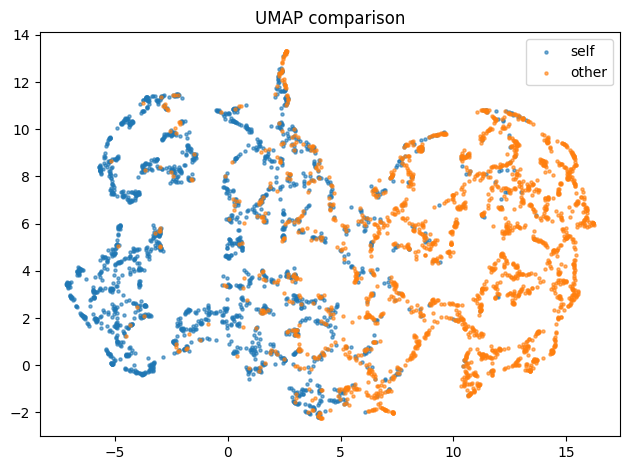

In [7]:
# Requires: pip install "hypergrid[umap]"
g_base.compare_umap(g_shifted)